In [96]:
# basic imports

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph

# quantum imports
from qiskit_optimization.applications import Maxcut
from qiskit.circuit import Parameter,QuantumCircuit
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import efficient_su2
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit.circuit.library import QAOAAnsatz
# SciPy minimizer routine
from scipy.optimize import minimize
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2
from qiskit_aer import AerSimulator

In [97]:
from itertools import combinations

import numpy as np
import rustworkx as rx
from scipy.optimize import minimize

from qiskit.circuit.library import efficient_su2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session
from rustworkx.visualization import mpl_draw

service = QiskitRuntimeService()
backend = AerSimulator(method='matrix_product_state')

estimator = BackendEstimatorV2(backend=backend)
sampler = BackendSamplerV2(backend=backend)

In [98]:
def calc_cut_size(graph, partition0, partition1):
    """Calculate the cut size of the given partitions of the graph."""

    cut_size = 0
    for edge0, edge1 in graph.edge_list():
        if edge0 in partition0 and edge1 in partition1:
            cut_size += 1
        elif edge0 in partition1 and edge1 in partition0:
            cut_size += 1
    return cut_size

In [118]:
num_nodes = 20  # Number of nodes in graph
graph = rx.undirected_gnp_random_graph(num_nodes, 0.3, seed=42)

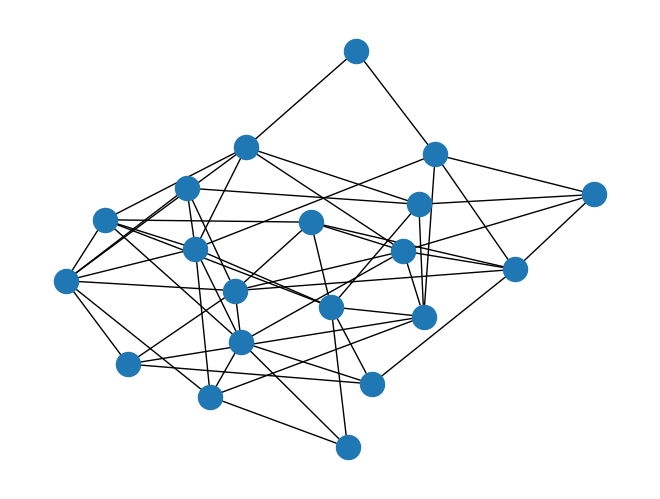

In [119]:
mpl_draw(rx.undirected_gnp_random_graph(num_nodes, 0.3, seed=42))

In [120]:
import networkx as nx

nx_graph = nx.Graph()
nx_graph.add_nodes_from(range(num_nodes))

In [121]:
for edge in graph.edge_list():
    nx_graph.add_edge(edge[0], edge[1])

In [122]:
curr_cut_size, partition = nx.approximation.one_exchange(nx_graph, seed=1)
print(f"Initial cut size: {curr_cut_size}")

Initial cut size: 40


### Deciding on Number of Qubits based on the compression

In [123]:
from pce import PauliCorrelationEncoding, MaxCutUtility
from qubo_to_maxcut import QUBO


from pce.pauli_correlation_encoding import PauliCorrelationEncoding


pauli_encoder = PauliCorrelationEncoding()

# User choice
k = 2


num_qubits = pauli_encoder.find_n(num_nodes, k)
print(f"Number of qubits required for k={k}: {num_qubits}")

Number of qubits required for k=2: 5


In [124]:

pauli_strings = SparsePauliOp(pauli_encoder.generate_pauli_strings(num_qubits,num_nodes, k))


print(f"We can encode the problem with {num_qubits} qubits using {len(pauli_strings)} Pauli strings using k={k} compression,\n which are {pauli_strings}")



We can encode the problem with 5 qubits using 20 Pauli strings using k=2 compression,
 which are SparsePauliOp(['XXIII', 'XIXII', 'XIIXI', 'XIIIX', 'IXXII', 'IXIXI', 'IXIIX', 'IIXXI', 'IIXIX', 'IIIXX', 'YYIII', 'YIYII', 'YIIYI', 'YIIIY', 'IYYII', 'IYIYI', 'IYIIY', 'IIYYI', 'IIYIY', 'IIIYY'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j])


In [125]:
list_size = num_nodes // 3
node_x = [i for i in range(list_size)]
node_y = [i for i in range(list_size, 2 * list_size)]
node_z = [i for i in range(2 * list_size, num_nodes)]

print("List 1:", node_x)
print("List 2:", node_y)
print("List 3:", node_z)

List 1: [0, 1, 2, 3, 4, 5]
List 2: [6, 7, 8, 9, 10, 11]
List 3: [12, 13, 14, 15, 16, 17, 18, 19]


In [126]:
def build_pauli_correlation_encoding(pauli, node_list, n, k=2):
    pauli_correlation_encoding = []
    for idx, c in enumerate(combinations(range(n), k)):
        if idx >= len(node_list):
            break
        paulis = ["I"] * n
        paulis[c[0]], paulis[c[1]] = pauli, pauli
        pauli_correlation_encoding.append(("".join(paulis)[::-1], 1))

    hamiltonian = []
    for pauli, weight in pauli_correlation_encoding:
        hamiltonian.append(SparsePauliOp.from_list([(pauli, weight)]))

    return hamiltonian


pauli_correlation_encoding_x = build_pauli_correlation_encoding(
    "X", node_x, num_qubits
)
pauli_correlation_encoding_y = build_pauli_correlation_encoding(
    "Y", node_y, num_qubits
)
pauli_correlation_encoding_z = build_pauli_correlation_encoding(
    "Z", node_z, num_qubits
)

### QUantum Execution

In [127]:
# Build the quantum circuit
qc = efficient_su2(num_qubits, ["ry", "rz"], reps=2)

In [128]:
# Optimize the circuit

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc = pm.run(qc)

### Loss Function

For the loss function LL, we use a relaxation of the Max-Cut objective function as described in [1], which is defined as V(x)≔∑(i,j)∈EWi,j(1−xixj)V(x):=∑(i,j)∈E​Wi,j​(1−xi​xj​). Here, Wi,jWi,j​ denotes the weight of the edge (i,j)(i,j), and xixi​ represents the partition of node ii. The loss function LL is given by:

L≔∑(i,j)∈EWi,jtanh(α⟨∏i⟩)tanh(α⟨∏j⟩)+L(reg)L:=∑(i,j)∈E​Wi,j​tanh(α⟨∏i​⟩)tanh(α⟨∏j​⟩)+L(reg)

where the Max-Cut objective function is replaced by the smooth hyperbolic tangents of the expectation values of the Pauli strings encoding the nodes. The regularization term L(reg)L(reg) and the rescaling factor αα, proportional to the number of qubits, are introduced to improve the solver's performance.

The regularization term is defined as:

L(reg)L(reg) is defined as L(reg)≔βν[1m∑i∈Vtanh(α⟨∏i⟩)2]2L(reg):=βν[m1​∑i∈V​tanh(α⟨∏i​⟩)2]2

where β=1/2β=1/2, ν=∣E∣/2+(m−1)/4ν=∣E∣/2+(m−1)/4, and mm is the number of nodes in the graph.

In [129]:
def flatten_hamiltonian_terms(hamiltonian):
    if isinstance(hamiltonian, SparsePauliOp):
        return [op for op in hamiltonian]

    flattened = []
    for item in hamiltonian:
        if isinstance(item, list):
            flattened.extend(item)
        else:
            flattened.append(item)
    return flattened


def loss_func_estimator(x, ansatz, hamiltonian, estimator, graph):
    """
    Calculates the specified loss function for the given ansatz, Hamiltonian, and graph.

    The expectation values of each Pauli string in the Hamiltonian are first obtained
    by running the ansatz on the quantum backend. These expectation values are then
    passed through the nonlinear function tanh(alpha * prod_i). The loss function is
    subsequently computed from these transformed values.
    """
    observables = flatten_hamiltonian_terms(hamiltonian)
    job = estimator.run([(ansatz, observables, x)])
    result = job.result()[0]

    # calculate the loss function
    node_exp_map = {}
    for idx, ev in enumerate(np.atleast_1d(result.data.evs)):
        node_exp_map[idx] = ev

    loss = 0
    alpha = num_qubits
    for edge0, edge1 in graph.edge_list():
        loss += np.tanh(alpha * node_exp_map[edge0]) * np.tanh(
            alpha * node_exp_map[edge1]
        )

    regulation_term = 0
    for i in range(len(graph.nodes())):
        regulation_term += np.tanh(alpha * node_exp_map[i]) ** 2
    regulation_term = regulation_term / len(graph.nodes())
    regulation_term = regulation_term**2
    beta = 1 / 2
    v = len(graph.edges()) / 2 + (len(graph.nodes()) - 1) / 4
    regulation_term = beta * v * regulation_term

    loss = loss + regulation_term

    global experiment_result
    print(f"Iter {len(experiment_result)}: {loss}")
    experiment_result.append({"loss": loss, "exp_map": node_exp_map})
    return loss

### Execute

In [130]:
pce = [op.apply_layout(qc.layout) for op in pauli_strings]

In [131]:
print(pce)

[SparsePauliOp(['XXIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIXII'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIIXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXXII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXIXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIXXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIXIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIXX'],
              coeffs=[1.+0.j]), SparsePauliOp(['YYIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['YIYII'],
              coeffs=[1.+0.j]), SparsePauliOp(['YIIYI'],
              coeffs=[1.+0.j]), SparsePauliOp(['YIIIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYYII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYIYI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYIIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIYYI'],
     

In [132]:
print(pauli_strings)

SparsePauliOp(['XXIII', 'XIXII', 'XIIXI', 'XIIIX', 'IXXII', 'IXIXI', 'IXIIX', 'IIXXI', 'IIXIX', 'IIIXX', 'YYIII', 'YIYII', 'YIIYI', 'YIIIY', 'IYYII', 'IYIYI', 'IYIIY', 'IIYYI', 'IIYIY', 'IIIYY'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j])


In [133]:
# Run the optimization using Session

with Session(backend=backend) as session:
    estimator = Estimator(mode=session)

    experiment_result = []

    def loss_func(x):
        return loss_func_estimator(x, qc, pce, estimator, graph)

    np.random.seed(42)
    initial_params = np.random.rand(qc.num_parameters)
    result = minimize(
        loss_func, initial_params, method="COBYLA", options={"maxiter": 50}
    )
print(result)

Iter 0: 4.6907508040848285
Iter 1: 0.9193445303508683
Iter 2: -0.6514318486282065
Iter 3: 3.915828316458096
Iter 4: 0.9699127789753335
Iter 5: 1.2414739956432435
Iter 6: 0.9078459771795773
Iter 7: -2.147903127373869
Iter 8: -2.126520059871649
Iter 9: -1.6094405909223193
Iter 10: -2.5214444160089764
Iter 11: -2.9523947360566947
Iter 12: 0.594238843271425
Iter 13: -3.756278477779352
Iter 14: -2.3119814192320334
Iter 15: -4.656905216953316
Iter 16: 3.5375173042470616
Iter 17: -1.1609764791600474
Iter 18: -4.854631564941661
Iter 19: -3.8578406455494942
Iter 20: -4.937317964878703
Iter 21: -4.627085576846401
Iter 22: -3.2935016059964006
Iter 23: -6.052977941178227
Iter 24: -5.5917574175416815
Iter 25: -3.5518012627156934
Iter 26: -1.4811442249356248
Iter 27: -1.4422404536258888
Iter 28: -5.451154088775156
Iter 29: -4.205739977122878
Iter 30: -2.530482874125532
Iter 31: -0.45292262889468593
Iter 32: -6.015052584120135
Iter 33: -4.282128021983986
Iter 34: -5.640908847600688
Iter 35: -3.974182

#### Post Process and Return Desired Classical format result

In [134]:
# Calculate the partitions based on the final expectation values
# If the expectation value is positive, the node belongs to partition 0 (par0)
# Otherwise, the node belongs to partition 1 (par1)

par0, par1 = set(), set()

for i in experiment_result[-1]["exp_map"]:
    if experiment_result[-1]["exp_map"][i] >= 0:
        par0.add(i)
    else:
        par1.add(i)
print(par0, par1)

{0, 3, 6, 7, 8, 9, 10, 13, 15, 16, 19} {1, 2, 4, 5, 11, 12, 14, 17, 18}


In [135]:
cut_size = calc_cut_size(graph, par0, par1)
print(f"Cut size: {cut_size}")


Cut size: 35


Now perform one round of single bit swap search

In [136]:
best_bits = []
cur_bits = []

for i in experiment_result[-1]["exp_map"]:
    if experiment_result[-1]["exp_map"][i] >= 0:
        cur_bits.append(1)
    else:
        cur_bits.append(0)
print(cur_bits)

[1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1]


In [137]:
# Swap the partitions and calculate the cut size
best_cut = 0
for edge0, edge1 in graph.edge_list():
    swapped_bits = cur_bits.copy()
    swapped_bits[edge0], swapped_bits[edge1] = (
        swapped_bits[edge1],
        swapped_bits[edge0],
    )

    cur_partition = [set(), set()]
    for i, bit in enumerate(swapped_bits):
        if bit > 0:
            cur_partition[0].add(i)
        else:
            cur_partition[1].add(i)
    cut_size = calc_cut_size(graph, cur_partition[0], cur_partition[1])
    if best_cut < cut_size:
        best_cut = cut_size
        best_bits = swapped_bits

print(best_cut, best_bits)

37 [1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1]
